# 🚗 Used Car Price Prediction — Exploratory Data Analysis

> **Project Goal:** Analyze used car data to understand the key factors affecting selling price,  
> as a foundation for building a Machine Learning price prediction model.

---

### 📋 Notebook Structure
| # | Section |
|---|--------|
| 1 | Imports & Configuration |
| 2 | Load Data |
| 3 | Data Overview |
| 4 | Data Cleaning |
| 5 | Univariate Analysis |
| 6 | Bivariate Analysis |
| 7 | Multivariate Analysis |
| 8 | Outlier Analysis |
| 9 | Feature Engineering |
| 10 | Key Insights & Summary |

---
## 1. 📦 Imports & Configuration

In [1]:
# ── Core libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization libraries ─────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Plot configuration ───────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

print('✅ Setup complete — libraries loaded.')

✅ Setup complete — libraries loaded.


---
## 2. 📂 Load Data

In [2]:
# ── Load the raw dataset ─────────────────────────────────────────
df = pd.read_csv('data/cardekho_dataset.csv')

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 15,411 rows × 14 columns


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
print("\n" + "="*50)
print("DATA QUALITY REPORT")
print("="*50)
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
print(f"\nTotal missing before: {df.isnull().sum().sum()}")


DATA QUALITY REPORT
Missing values before cleaning:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing before: 0


---
## 3. 🔍 Data Overview

In [4]:
# ── Column types & null counts ───────────────────────────────────
df.info()

print('\n── Missing values per column ──')
print(df.isnull().sum())

print(f'\n── Duplicate rows: {df.duplicated().sum()} ──')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB

── Missing values per column ──
Unnamed: 0           0
car_n

In [5]:
# ── Descriptive statistics for numeric columns ───────────────────
df.describe().round(2)

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00,15411.00
mean,9811.86,6.04,55616.48,19.70,1486.06,100.59,5.33,774971.12
std,5643.42,3.01,51618.55,4.17,521.11,42.97,0.81,894128.36
min,0.00,0.00,100.00,4.00,793.00,38.40,0.00,40000.00
25%,4906.50,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,9872.00,6.00,50000.00,19.67,1248.00,88.50,5.00,556000.00
75%,14668.50,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,19543.00,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


---
## 4. 🧹 Data Cleaning

Steps performed:
1. Drop the auto-index column `Unnamed: 0`
2. Remove duplicate rows
3. Fill missing values (median for numeric, mode for categorical)
4. Remove rows where `seats == 0` (physically invalid)
5. Remove high-price outliers using the IQR method

In [6]:
# ── Step 1: Drop useless index column ───────────────────────────
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
    print('Dropped: Unnamed: 0')

# ── Step 2: Remove duplicates ────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)} rows → Shape now: {df.shape}')

# ── Step 3: Fill missing values ──────────────────────────────────
numeric_cols     = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include='object').columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Missing values remaining: {df.isnull().sum().sum()}')

# ── Step 4: Remove invalid seat entries ──────────────────────────
df = df[df['seats'] > 0]
print(f'After removing seats=0 → Shape: {df.shape}')

# ── Step 5: Remove outliers (IQR on selling_price) ───────────────
Q1    = df['selling_price'].quantile(0.25)
Q3    = df['selling_price'].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

n_out = len(df[df['selling_price'] > upper])
df    = df[(df['selling_price'] >= lower) & (df['selling_price'] <= upper)]

print(f'Outliers removed: {n_out} high-price rows')
print(f'\n✅ Final clean shape: {df.shape}')

Dropped: Unnamed: 0


Duplicates removed: 167 rows → Shape now: (15244, 13)
Missing values remaining: 0
After removing seats=0 → Shape: (15242, 13)
Outliers removed: 1371 high-price rows

✅ Final clean shape: (13871, 13)


In [7]:
# Remove extreme outliers from engine and max_power (99th percentile)
for col in ['engine', 'max_power', 'mileage']:
    upper_99 = df[col].quantile(0.99)
    before = len(df)
    df = df[df[col] <= upper_99]
    print(f"Removed {before - len(df)} outliers from {col}")

Removed 138 outliers from engine
Removed 128 outliers from max_power
Removed 94 outliers from mileage


In [8]:
print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")


Missing values after cleaning: 0


In [9]:
# ── Re-identify column groups after cleaning ─────────────────────
# (re-run this after any structural change to df)
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print('Numeric columns:    ', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns:     ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Categorical columns: ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


---
## 5. 📊 Univariate Analysis
Examining each variable individually to understand its distribution and spread.

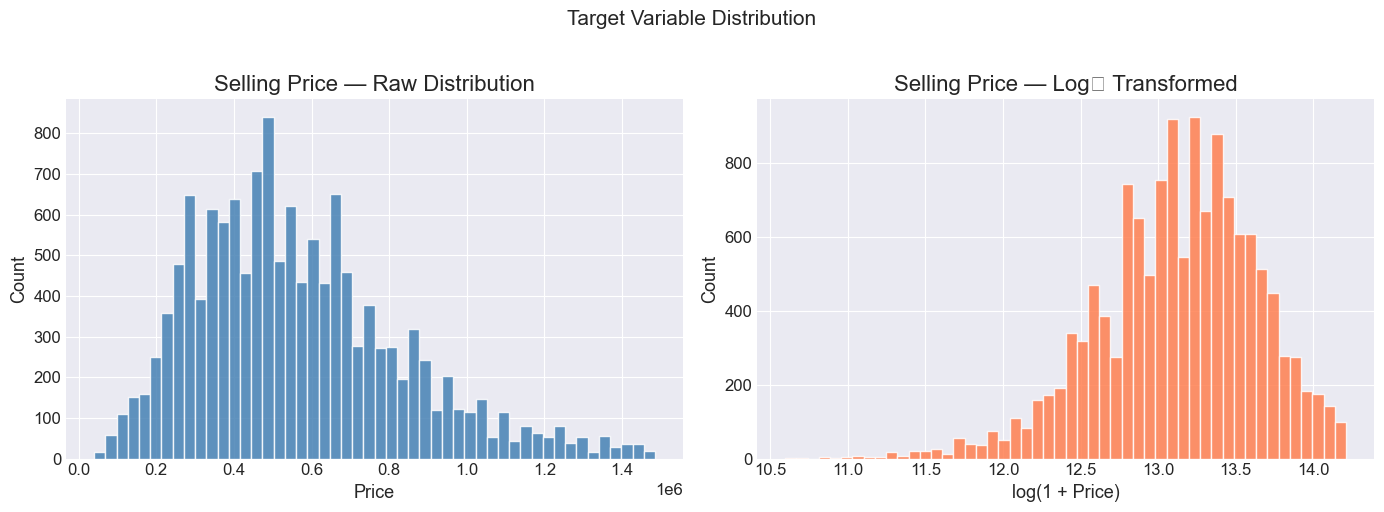

Skewness (raw):  0.810
Skewness (log):  -0.576


In [10]:
# ── Target variable: Selling Price distribution ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original scale
axes[0].hist(df['selling_price'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Selling Price — Raw Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Log scale (normalises the right skew — useful for modelling)
log_price = np.log1p(df['selling_price'])
axes[1].hist(log_price, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Selling Price — Log₁ Transformed')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness (raw):  {df['selling_price'].skew():.3f}")
print(f'Skewness (log):  {log_price.skew():.3f}')

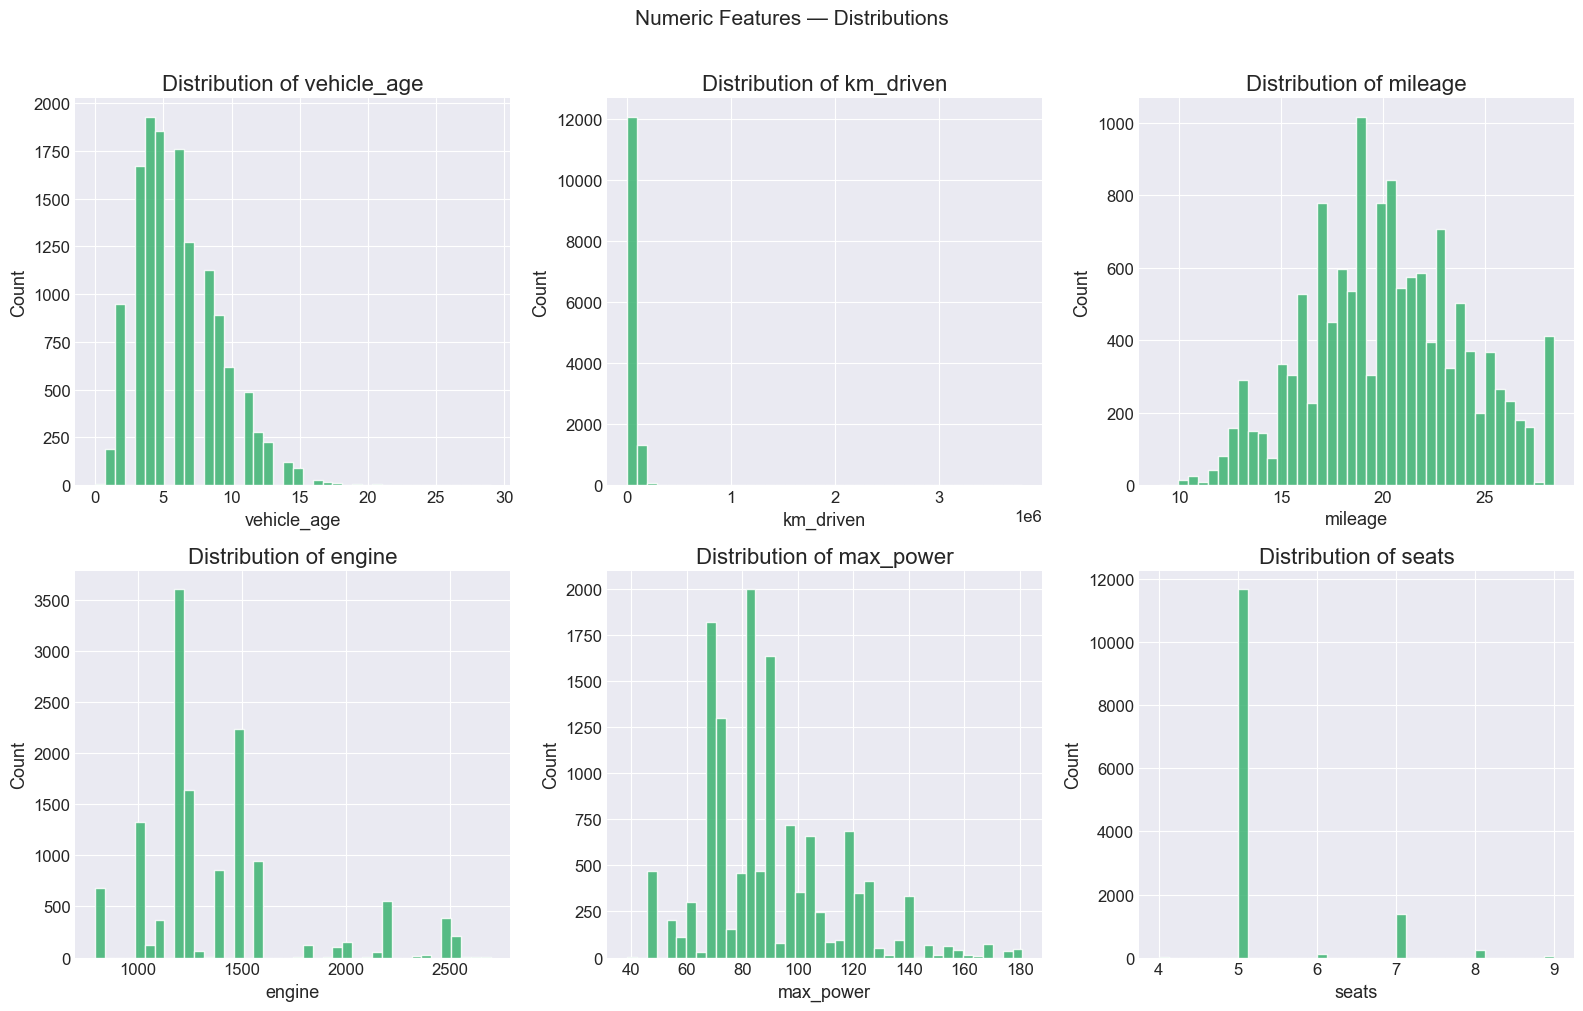

── Skewness ──
vehicle_age     0.847
km_driven      29.909
mileage         0.048
engine          1.389
max_power       0.915
seats           2.486
dtype: float64


In [11]:
# ── Numeric features distributions ──────────────────────────────
num_features = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='mediumseagreen', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Features — Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Skewness summary
print('── Skewness ──')
print(df[num_features].skew().round(3))

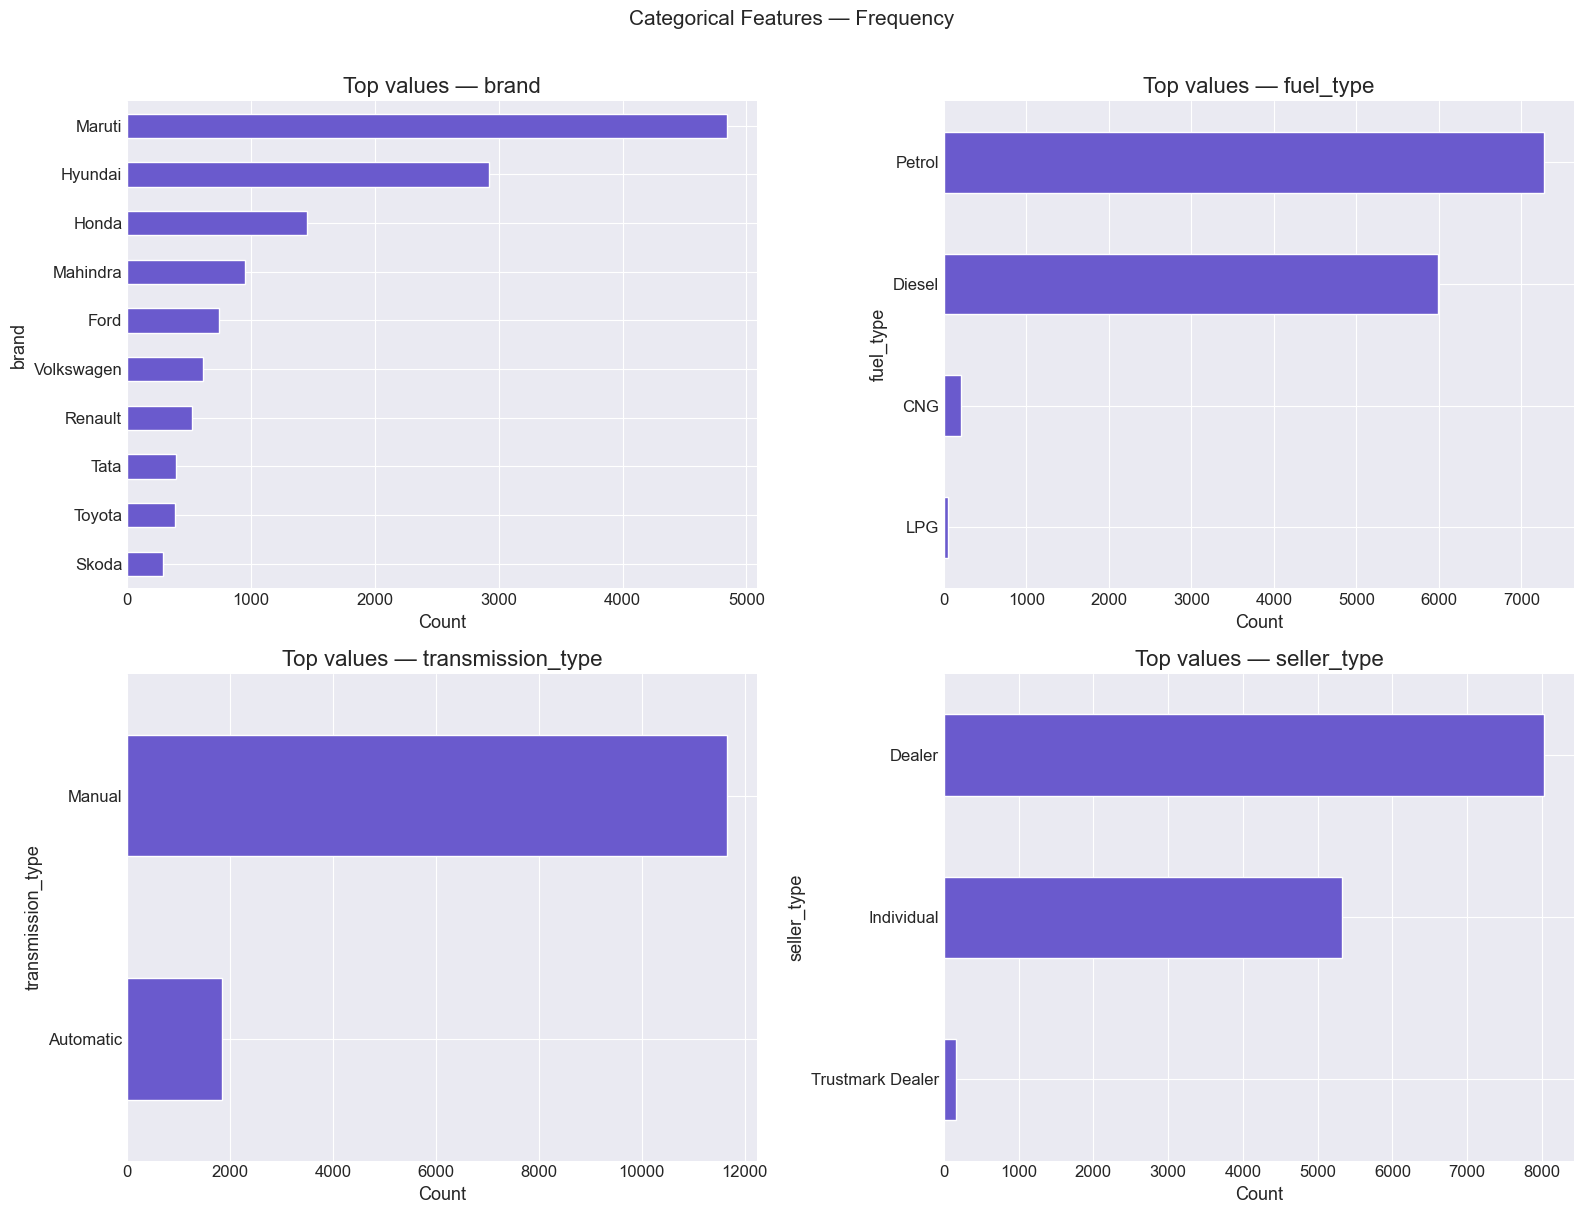

In [12]:
# ── Categorical features: value counts & bar charts ──────────────
cat_features = ['brand', 'fuel_type', 'transmission_type', 'seller_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    top = df[col].value_counts().head(10)
    top.plot(kind='barh', ax=axes[i], color='slateblue', edgecolor='white')
    axes[i].set_title(f'Top values — {col}')
    axes[i].set_xlabel('Count')
    axes[i].invert_yaxis()  # highest bar on top

plt.suptitle('Categorical Features — Frequency', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

---
## 6. 🔗 Bivariate Analysis
How does each feature relate to the target variable (`selling_price`)?

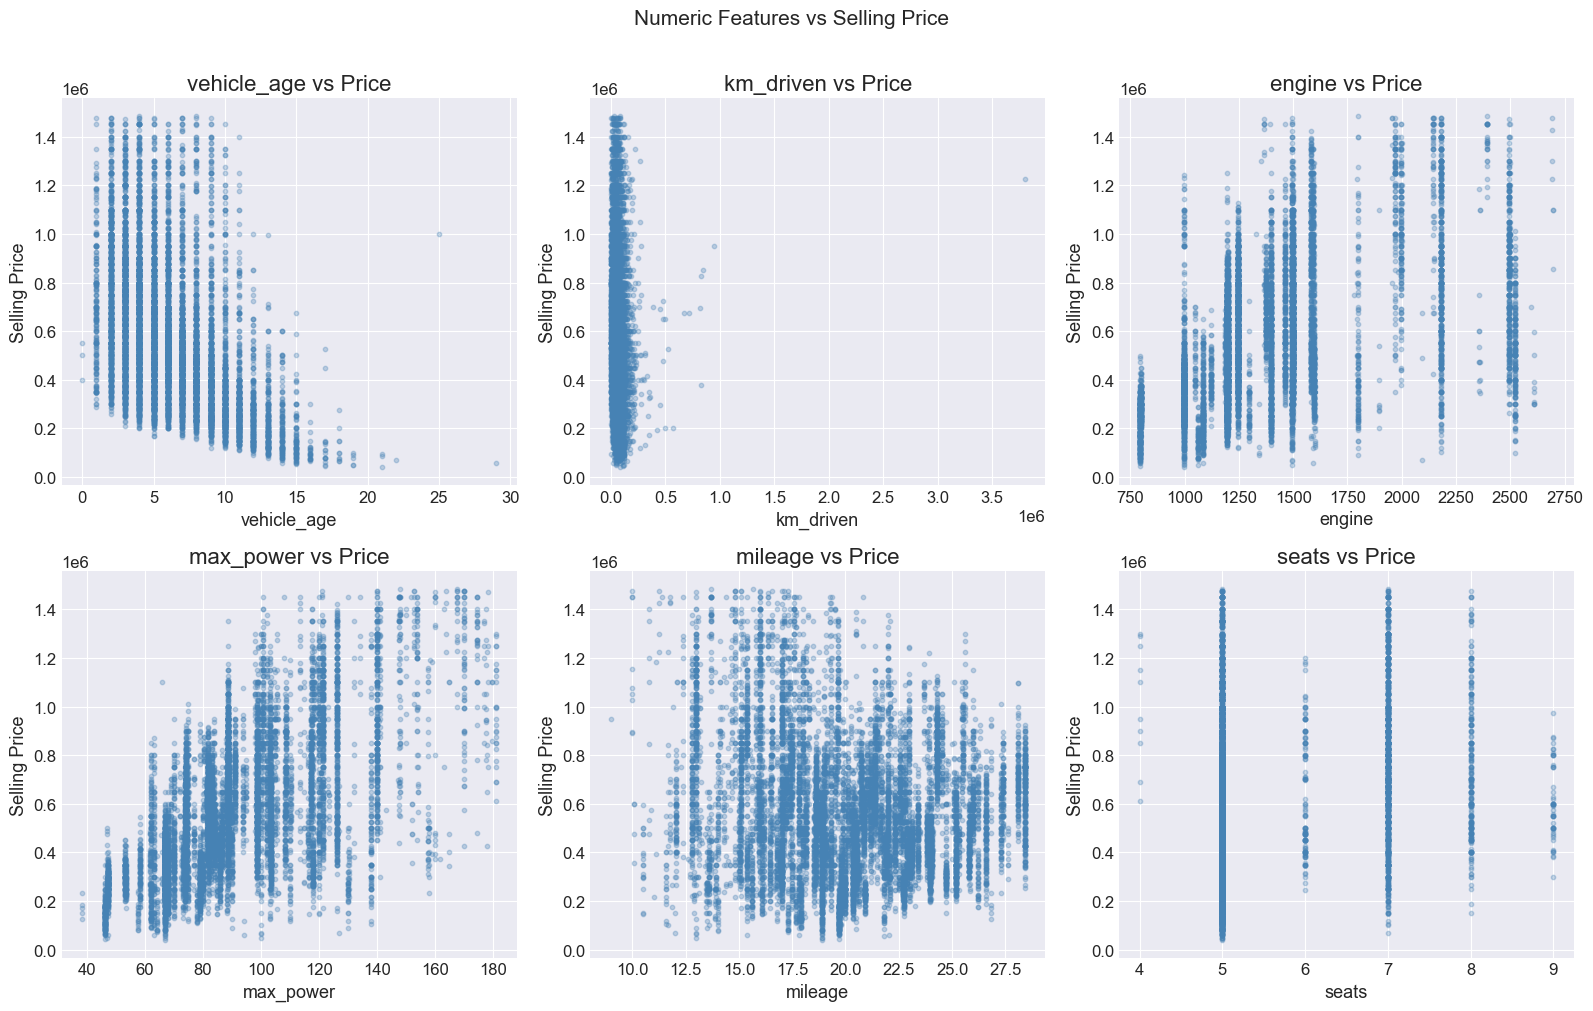

In [13]:
# ── Numeric features vs. selling price (scatter plots) ──────────
num_features = ['vehicle_age', 'km_driven', 'engine', 'max_power', 'mileage', 'seats']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['selling_price'], alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Selling Price')
    axes[i].set_title(f'{col} vs Price')

plt.suptitle('Numeric Features vs Selling Price', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

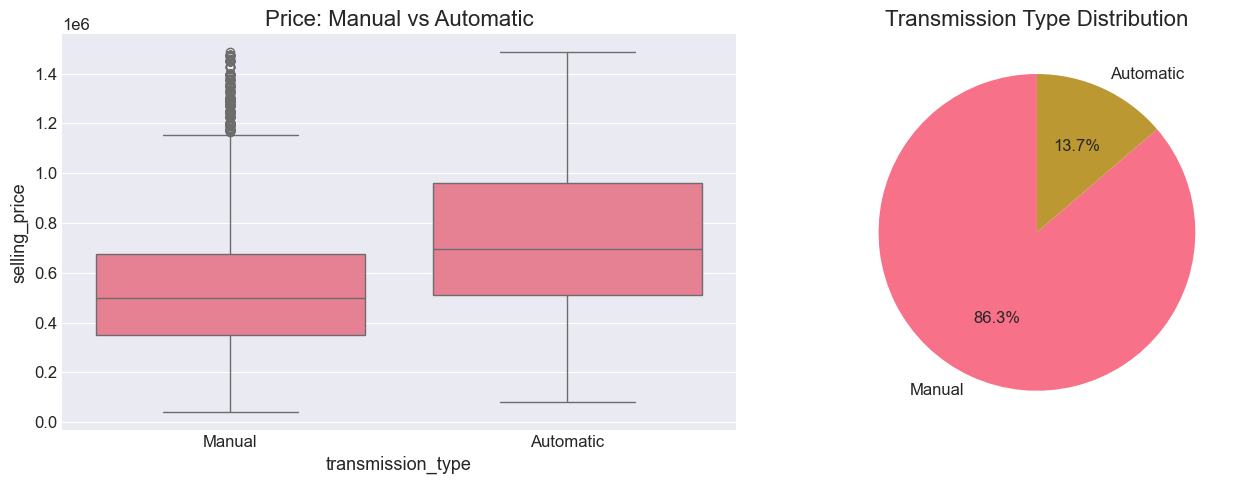

Manual average:         535,106
Automatic average:      752,796
Premium for Automatic: 40.7%


In [14]:
# ── Transmission type vs price ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='transmission_type', y='selling_price', data=df, ax=axes[0])
axes[0].set_title('Price: Manual vs Automatic')

df['transmission_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', ax=axes[1], startangle=90
)
axes[1].set_title('Transmission Type Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Numeric summary
manual_avg = df[df['transmission_type'] == 'Manual']['selling_price'].mean()
auto_avg   = df[df['transmission_type'] == 'Automatic']['selling_price'].mean()
print(f'Manual average:    {manual_avg:>12,.0f}')
print(f'Automatic average: {auto_avg:>12,.0f}')
print(f'Premium for Automatic: {((auto_avg - manual_avg) / manual_avg) * 100:.1f}%')

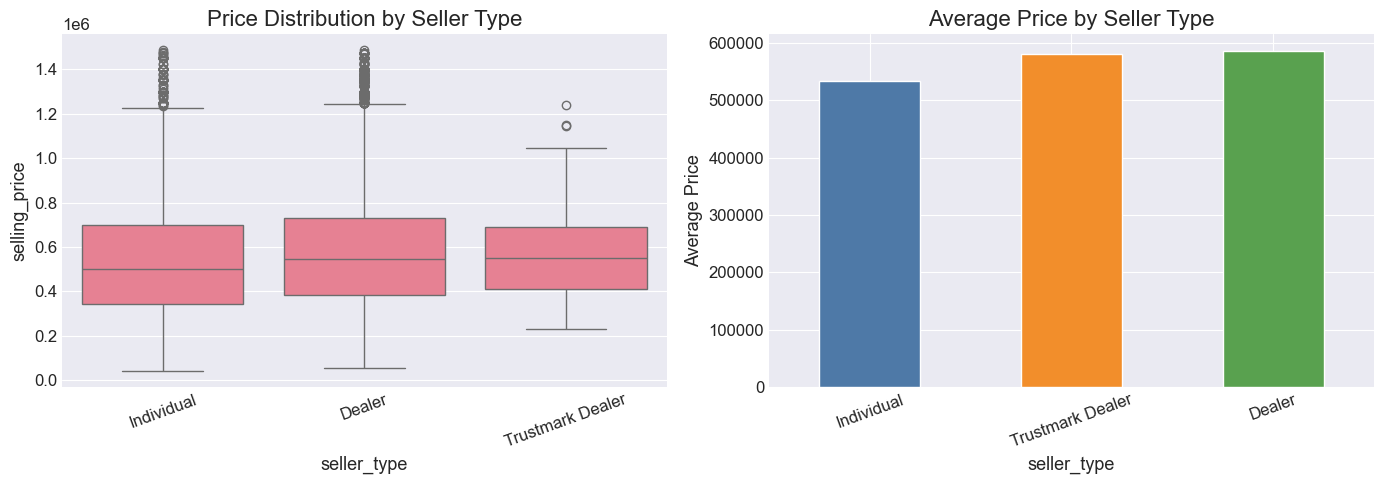

                      mean    median  count
seller_type                                
Dealer            585132.0  545000.0   8027
Individual        534041.0  500000.0   5324
Trustmark Dealer  580594.0  550000.0    160


In [15]:
# ── Seller type vs price ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='seller_type', y='selling_price', data=df, ax=axes[0])
axes[0].set_title('Price Distribution by Seller Type')
axes[0].tick_params(axis='x', rotation=20)

seller_avg = df.groupby('seller_type')['selling_price'].mean().sort_values()
seller_avg.plot(kind='bar', ax=axes[1], color=['#4E79A7', '#F28E2B', '#59A14F'], edgecolor='white')
axes[1].set_title('Average Price by Seller Type')
axes[1].set_ylabel('Average Price')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print(df.groupby('seller_type')['selling_price'].agg(['mean', 'median', 'count']).round(0))

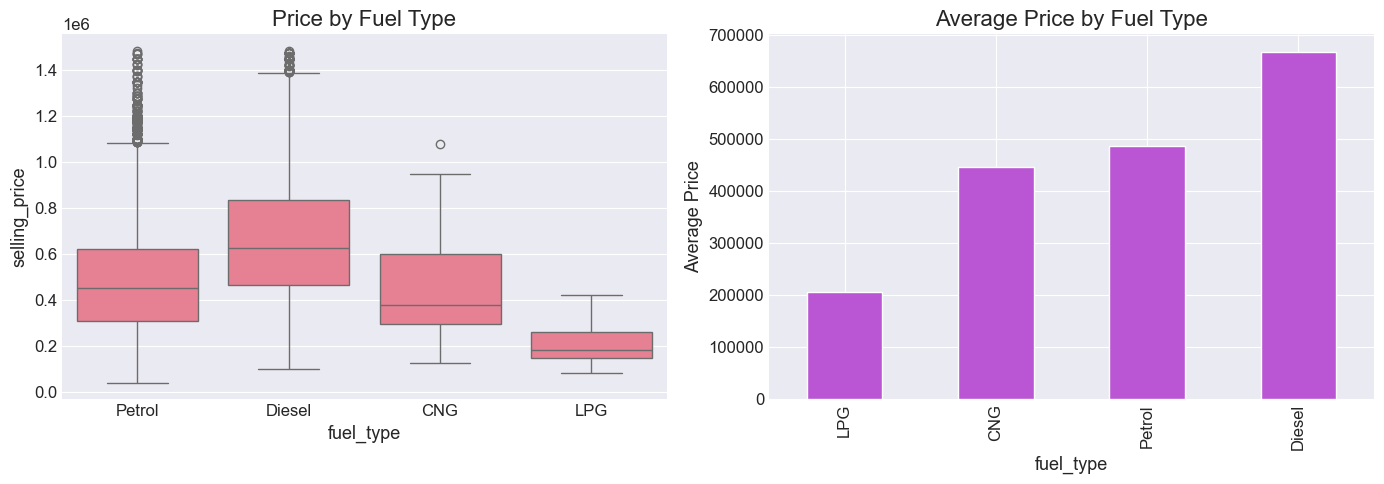

In [16]:
# ── Fuel type vs price ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='fuel_type', y='selling_price', data=df, ax=axes[0])
axes[0].set_title('Price by Fuel Type')

fuel_avg = df.groupby('fuel_type')['selling_price'].mean().sort_values()
fuel_avg.plot(kind='bar', ax=axes[1], color='mediumorchid', edgecolor='white')
axes[1].set_title('Average Price by Fuel Type')
axes[1].set_ylabel('Average Price')

plt.tight_layout()
plt.show()

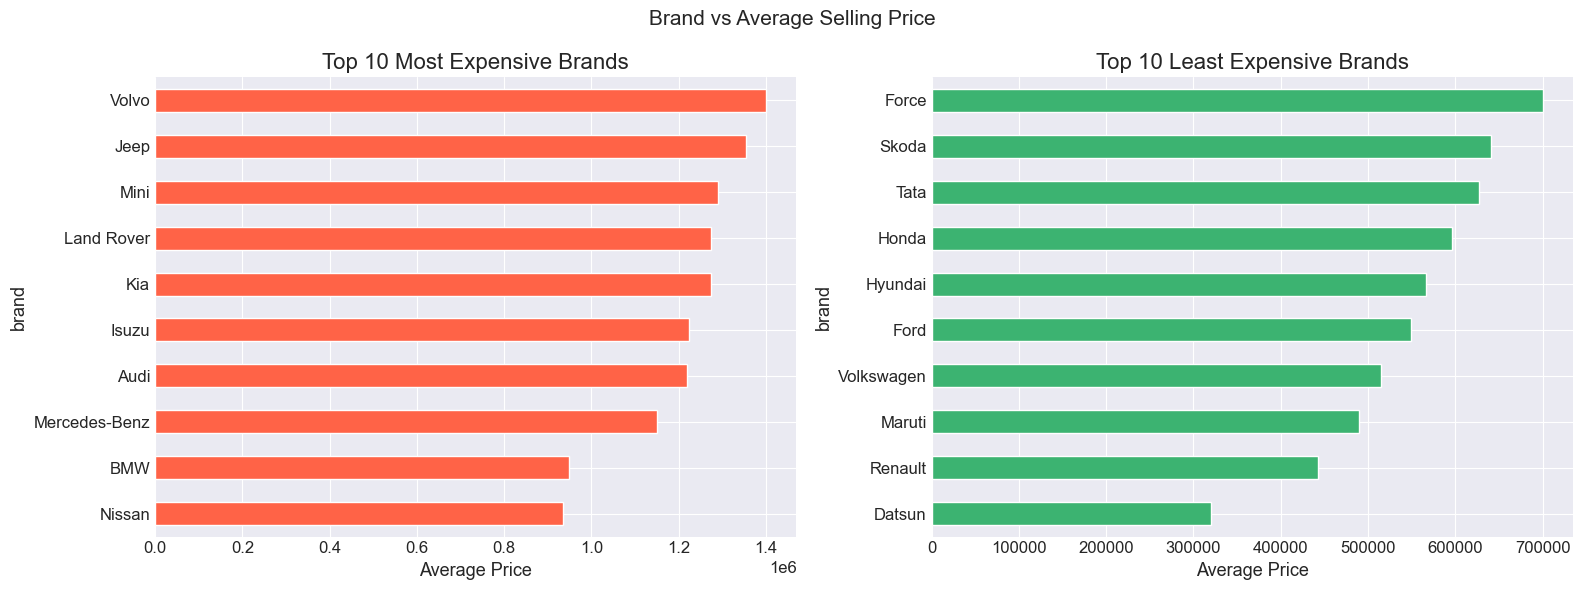

In [17]:
# ── Brand vs price (top & bottom 10) ────────────────────────────
brand_avg = df.groupby('brand')['selling_price'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

brand_avg.tail(10).plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Top 10 Most Expensive Brands')
axes[0].set_xlabel('Average Price')

brand_avg.head(10).plot(kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Top 10 Least Expensive Brands')
axes[1].set_xlabel('Average Price')

plt.suptitle('Brand vs Average Selling Price', fontsize=15)
plt.tight_layout()
plt.show()

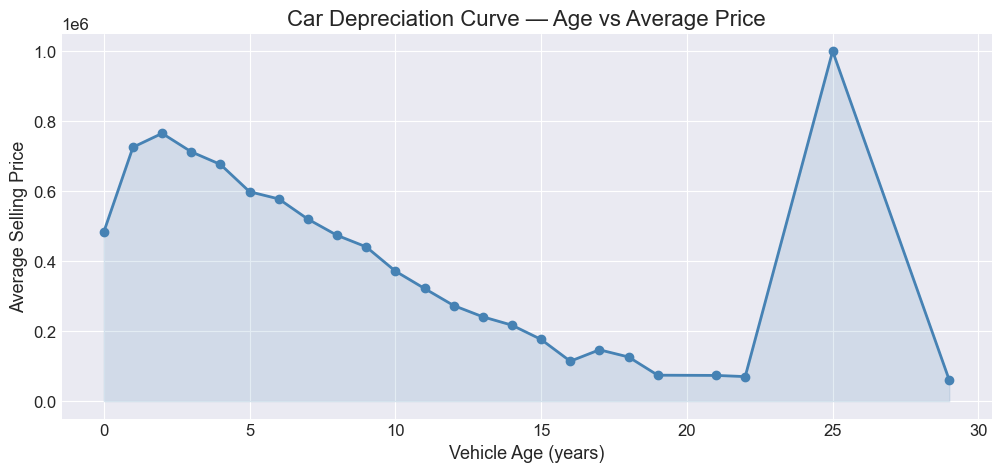

Average price by age group:
age_group
New (0-3)        730,913
Young (3-6)      618,813
Medium (6-10)    464,951
Old (10+)        267,324
Name: selling_price, dtype: object


In [18]:
# ── Depreciation curve: how price drops with vehicle age ─────────
age_price = df.groupby('vehicle_age')['selling_price'].mean()

plt.figure(figsize=(12, 5))
plt.plot(age_price.index, age_price.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(age_price.index, age_price.values, alpha=0.15, color='steelblue')
plt.title('Car Depreciation Curve — Age vs Average Price')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Average Selling Price')
plt.grid(True)
plt.show()

# Price by age group buckets
df['age_group'] = pd.cut(
    df['vehicle_age'],
    bins=[0, 3, 6, 10, 30],
    labels=['New (0-3)', 'Young (3-6)', 'Medium (6-10)', 'Old (10+)']
)

print('Average price by age group:')
print(df.groupby('age_group')['selling_price'].mean().apply(lambda x: f'{x:,.0f}'))

In [19]:
import plotly.express as px

fig = px.scatter(df.sample(500), x='vehicle_age', y='selling_price', 
                 color='transmission_type', title='Interactive: Age vs Price',
                 labels={'vehicle_age': 'Car Age (years)', 'selling_price': 'Price (EGP)'})
fig.show()

In [20]:
from scipy.stats import ttest_ind

auto = df[df['transmission_type'] == 'Automatic']['selling_price']
manual = df[df['transmission_type'] == 'Manual']['selling_price']
stat, p = ttest_ind(auto, manual)

print(f"T-test between Manual vs Automatic prices: p-value = {p:.6f}")
if p < 0.05:
    print("✅ Significant difference (p < 0.05)")
else:
    print("❌ No significant difference")

T-test between Manual vs Automatic prices: p-value = 0.000000
✅ Significant difference (p < 0.05)


---
## 7. 🔀 Multivariate Analysis
Looking at interactions between multiple features simultaneously.

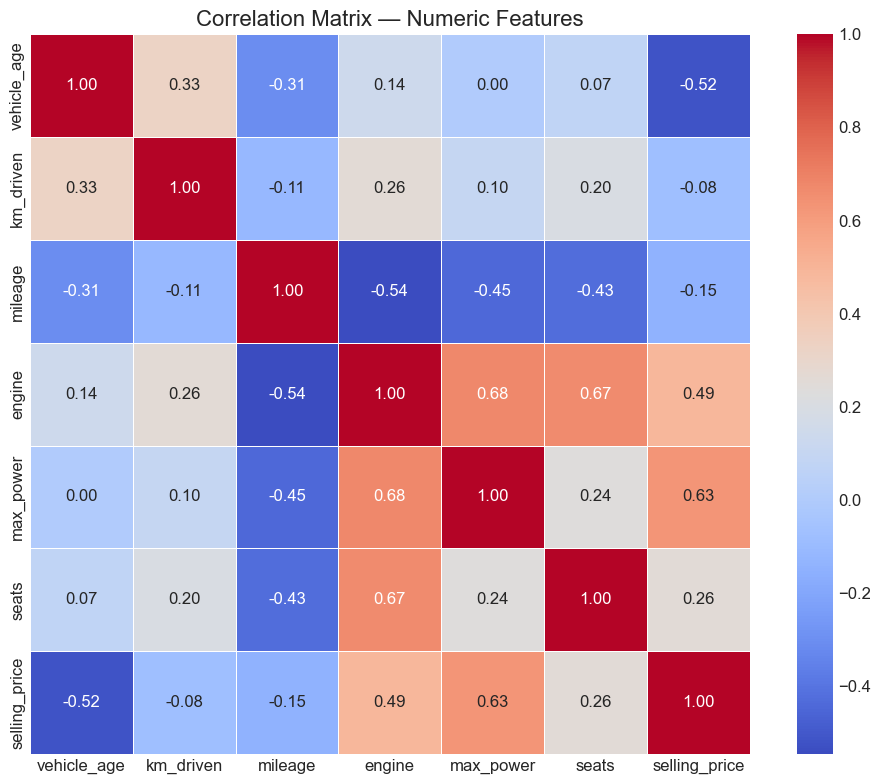

── Correlations with selling_price (sorted) ──
selling_price    1.000
max_power        0.626
engine           0.488
seats            0.257
km_driven       -0.080
mileage         -0.146
vehicle_age     -0.520
Name: selling_price, dtype: float64


In [21]:
# ── Correlation heatmap ──────────────────────────────────────────
# Only original numeric columns — no engineered features yet
corr_cols   = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

print('── Correlations with selling_price (sorted) ──')
print(corr_matrix['selling_price'].sort_values(ascending=False).round(3))

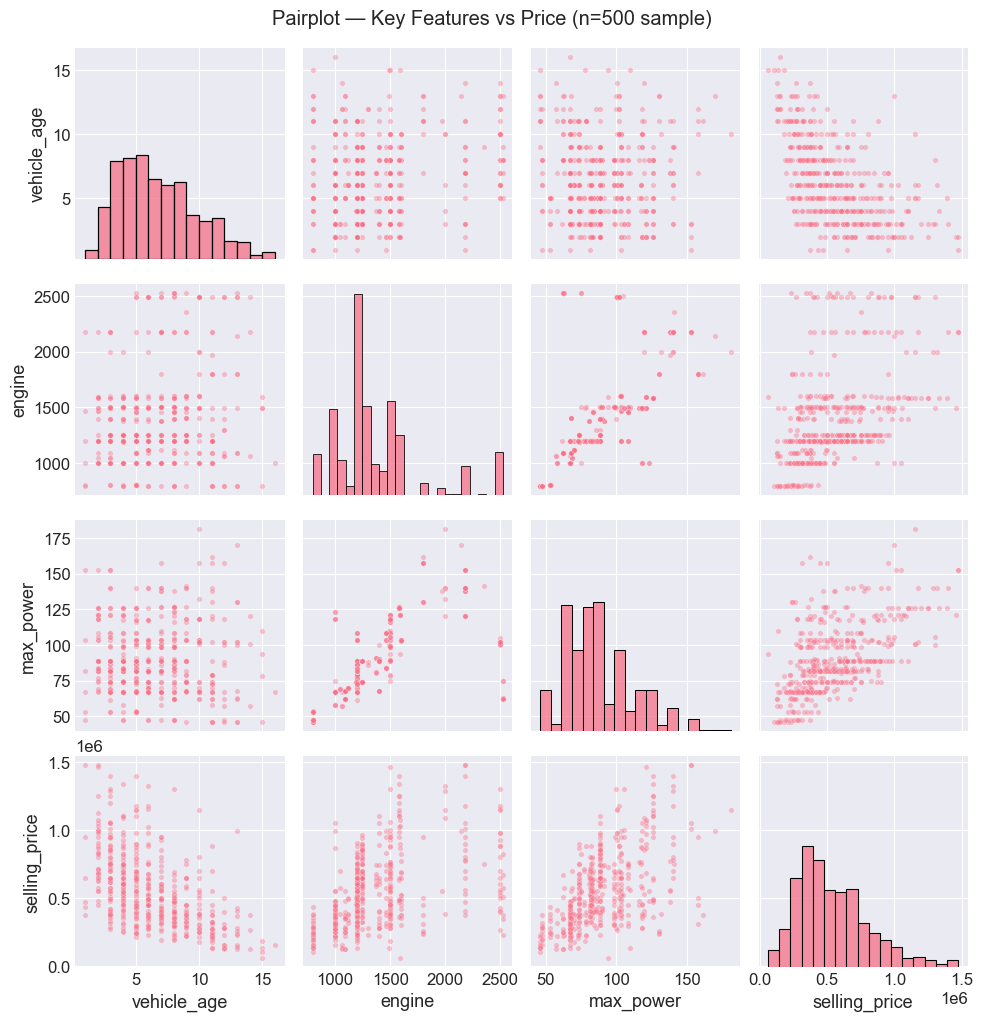

In [22]:
# ── Pairplot — key features only (sampled for speed) ────────────
sample = df.sample(500, random_state=42)

sns.pairplot(
    sample[['vehicle_age', 'engine', 'max_power', 'selling_price']],
    diag_kind='hist',
    plot_kws={'alpha': 0.4, 's': 15}
)
plt.suptitle('Pairplot — Key Features vs Price (n=500 sample)', y=1.02)
plt.show()

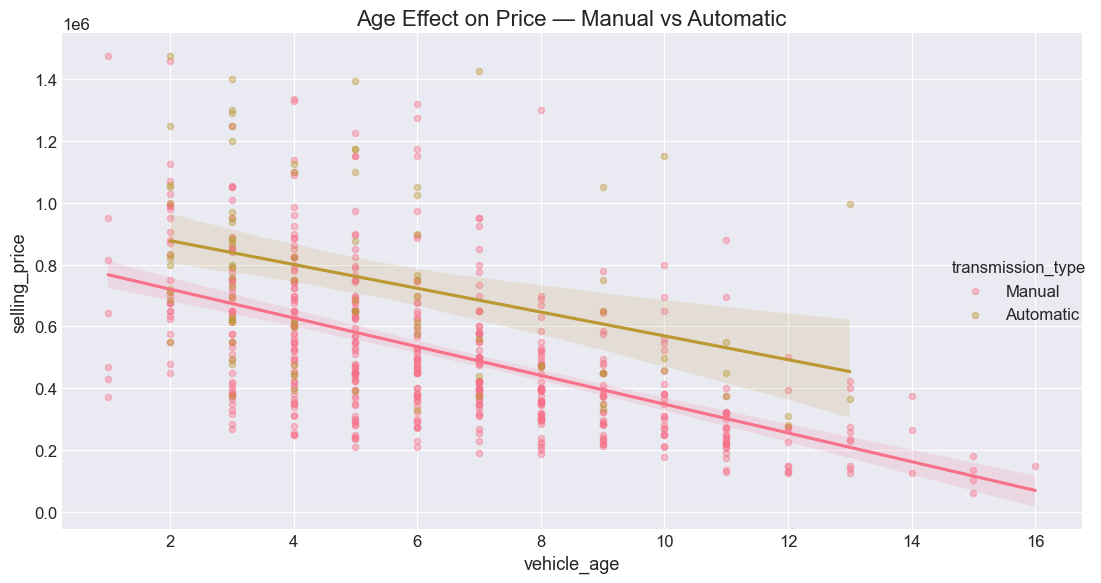

In [23]:
# ── Age vs price, split by transmission type ─────────────────────
# Uses a sample to keep rendering fast
sample = df.sample(600, random_state=42)

sns.lmplot(
    x='vehicle_age', y='selling_price',
    hue='transmission_type',
    data=sample,
    height=6, aspect=1.6,
    scatter_kws={'alpha': 0.4, 's': 20}
)
plt.title('Age Effect on Price — Manual vs Automatic')
plt.tight_layout()
plt.show()

---
## 8. 📦 Outlier Analysis
Re-inspecting the cleaned data for any remaining extreme values.

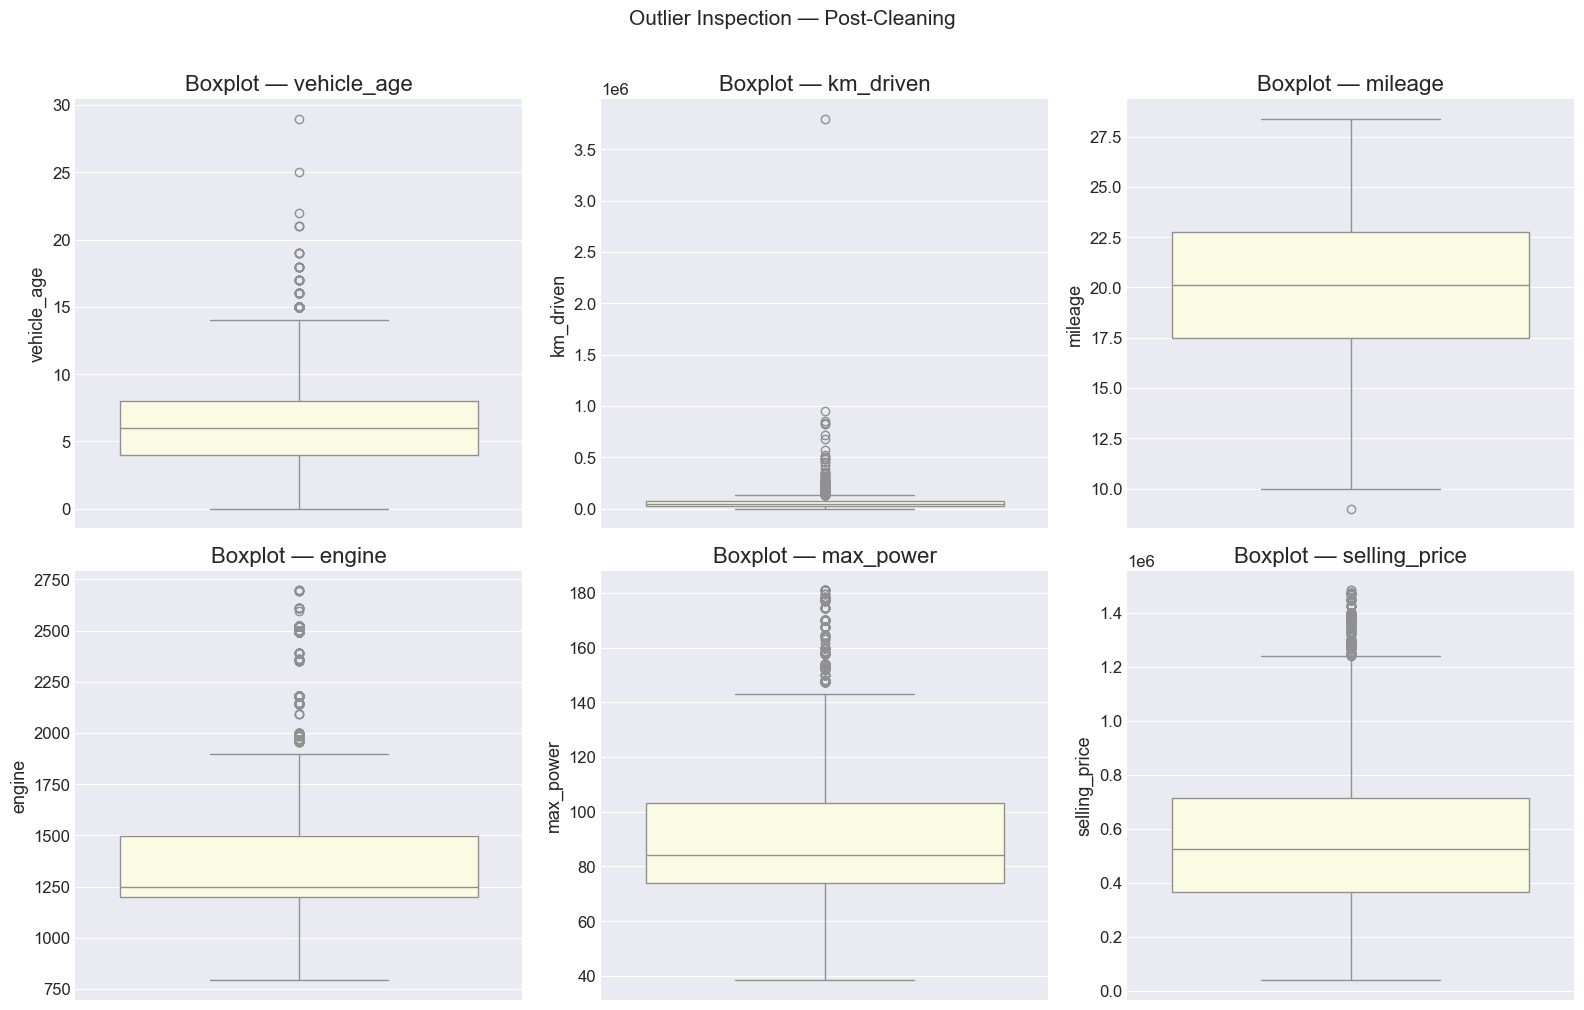

── IQR bounds summary ──
  vehicle_age          remaining outliers: 148
  km_driven            remaining outliers: 394
  mileage              remaining outliers: 1
  engine               remaining outliers: 1531
  max_power            remaining outliers: 367
  selling_price        remaining outliers: 335


In [24]:
# ── Box plots to spot remaining outliers in numeric features ─────
num_features = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'selling_price']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i], color='lightyellow')
    axes[i].set_title(f'Boxplot — {col}')

plt.suptitle('Outlier Inspection — Post-Cleaning', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# IQR summary table
print('── IQR bounds summary ──')
for col in num_features:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr    = q3 - q1
    n_out  = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f'  {col:<20} remaining outliers: {n_out}')

---
## 9. ⚙️ Feature Engineering
Creating new features that may improve model performance.

In [25]:
# ── Feature 1: log_price ──────────────────────────────────────────
# Reduces right skew in the target variable — helpful for linear models
df['log_price'] = np.log1p(df['selling_price'])

# ── Feature 2: price_per_km ───────────────────────────────────────
# Computed on raw km_driven (before any log transform) to keep meaning clear
# Represents value retention per kilometre driven
df['price_per_km'] = df['selling_price'] / df['km_driven']

# ── Feature 3: log_km ─────────────────────────────────────────────
# Log-transform km_driven to reduce its strong right skew
# Applied AFTER price_per_km is computed so that ratio stays valid
df['log_km'] = np.log1p(df['km_driven'])

# ── Feature 4: engine_per_seat ────────────────────────────────────
# Proxy for engine power relative to passenger capacity
df['engine_per_seat'] = df['engine'] / df['seats']

print('New features added: log_price, price_per_km, log_km, engine_per_seat')

# Quick correlation check for engineered features
eng_features = ['log_price', 'price_per_km', 'log_km', 'engine_per_seat']
print('\n── Correlation with selling_price ──')
print(df[eng_features + ['selling_price']].corr()['selling_price'].round(3))

New features added: log_price, price_per_km, log_km, engine_per_seat

── Correlation with selling_price ──
log_price          0.944
price_per_km       0.214
log_km            -0.166
engine_per_seat    0.491
selling_price      1.000
Name: selling_price, dtype: float64


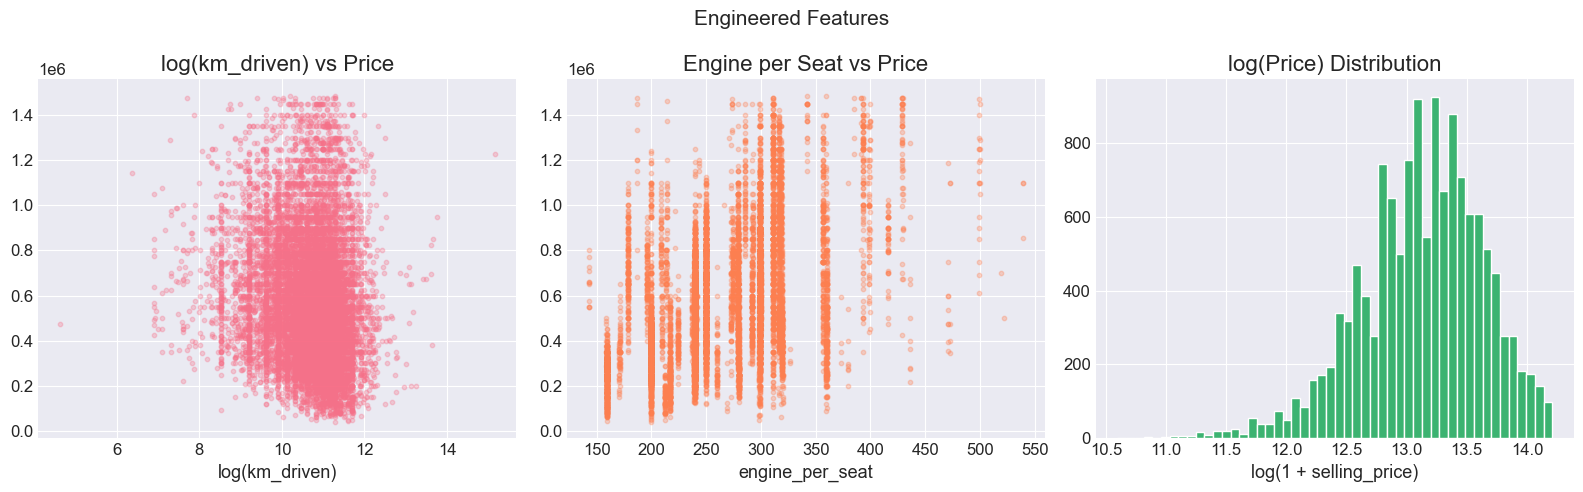

In [26]:
# ── Visualise engineered features vs price ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['log_km'],          df['selling_price'], alpha=0.3, s=10)
axes[0].set_title('log(km_driven) vs Price')
axes[0].set_xlabel('log(km_driven)')

axes[1].scatter(df['engine_per_seat'], df['selling_price'], alpha=0.3, s=10, color='coral')
axes[1].set_title('Engine per Seat vs Price')
axes[1].set_xlabel('engine_per_seat')

axes[2].hist(df['log_price'], bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('log(Price) Distribution')
axes[2].set_xlabel('log(1 + selling_price)')

plt.suptitle('Engineered Features', fontsize=15)
plt.tight_layout()
plt.show()

In [27]:
print("\n⚠️ WARNING: 'price_per_km' should NOT be used for training if predicting selling_price (data leakage).")
print("Remove it before model training.")


⚠️ WARNING: 'price_per_km' should NOT be used for training if predicting selling_price (data leakage).
Remove it before model training.


---
## 10. 💡 Key Insights & Summary

In [28]:
# ── Auto-generated insight statements ────────────────────────────
insights = []

# Correlation-based insights
corr = df[corr_cols].corr()['selling_price']

if corr['vehicle_age'] < 0:
    insights.append(f'📉 Older cars sell for less (correlation = {corr["vehicle_age"]:.2f})')

if corr['engine'] > 0:
    insights.append(f'🔧 Larger engines command higher prices (correlation = {corr["engine"]:.2f})')

if corr['max_power'] > 0:
    insights.append(f'⚡ More horsepower → higher price (correlation = {corr["max_power"]:.2f})')

if corr['mileage'] < 0:
    insights.append(f'⛽ Higher fuel efficiency is associated with lower price (correlation = {corr["mileage"]:.2f})')

# Transmission insight
manual_avg = df[df['transmission_type'] == 'Manual']['selling_price'].mean()
auto_avg   = df[df['transmission_type'] == 'Automatic']['selling_price'].mean()
pct        = ((auto_avg - manual_avg) / manual_avg) * 100
insights.append(f'🚗 Automatic cars are {pct:.1f}% more expensive than Manual on average')

# Common brand/fuel
insights.append(f'🏷️  Most common brand: {df["brand"].mode()[0]}')
insights.append(f'⛽ Most common fuel type: {df["fuel_type"].mode()[0]}')
insights.append(f'📅 Average vehicle age in dataset: {df["vehicle_age"].mean():.1f} years')

print('=' * 55)
print('           KEY EDA INSIGHTS')
print('=' * 55)
for i in insights:
    print(' •', i)
print('=' * 55)

           KEY EDA INSIGHTS
 • 📉 Older cars sell for less (correlation = -0.52)
 • 🔧 Larger engines command higher prices (correlation = 0.49)
 • ⚡ More horsepower → higher price (correlation = 0.63)
 • ⛽ Higher fuel efficiency is associated with lower price (correlation = -0.15)
 • 🚗 Automatic cars are 40.7% more expensive than Manual on average
 • 🏷️  Most common brand: Maruti
 • ⛽ Most common fuel type: Petrol
 • 📅 Average vehicle age in dataset: 6.1 years


In [29]:
# ── Export cleaned dataset for modelling ─────────────────────────
# Drop the helper age_group column (categorical with NaN edges) before saving
export_df = df.drop(columns=['age_group'], errors='ignore')
export_df.to_csv('processed_for_model.csv', index=False)

print(f'✅ Dataset saved → processed_for_model.csv')
print(f'   Shape: {export_df.shape[0]:,} rows × {export_df.shape[1]} columns')
print(f'   Columns: {export_df.columns.tolist()}')

✅ Dataset saved → processed_for_model.csv
   Shape: 13,511 rows × 17 columns
   Columns: ['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'log_price', 'price_per_km', 'log_km', 'engine_per_seat']


In [30]:
# Create a clean version for modeling (remove leakage columns)
model_ready = export_df.drop(
    columns=[
        'price_per_km',
        'log_price',
        'engine_per_seat'
    ]
, errors='ignore')
model_ready.to_csv('model_ready_no_leakage.csv', index=False)
print("✅ Model-ready data saved (no leakage columns)")

✅ Model-ready data saved (no leakage columns)
